### Testing Wind Ninja

Notebook contents 
* Creating a few small wind field time series to test Wind Ninja with
* Then, loading some test data and going from there...

created by Cassie Lumbrazo\
last updated: July 2025\
run location: UAS linux\
python environment: **rasterio**

In [2]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

from rasterio.warp import transform_bounds

In [3]:
from scipy import ndimage

In [4]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

# Wind Ninja Input Data 
* an elevation data file for the modeling area 
* a domain-averaged input wind speed and direction, and
* a specification of the dominant vegetation in the area 

## Starting with the DEM

In [5]:
# PREVIOUS CODE USED TO CREATE THE JUNEAU DEM FROM THE ARCTIC DEM

# # Open the ArcticDEM file
# filepath = '/hdd/snow_hydrology/DEMs/ArcticDEM/'
# filename =  '40_05_2_2_2m_v4.1_dem.tif'

# dem = rioxarray.open_rasterio(os.path.join(filepath, filename), masked=True)

# dem_wgs84 = dem.rio.reproject("EPSG:4326")
# dem_wgs84.rio.crs

# # Clip the ArcticDEM to the Juneau area
# # Define the bounding box for Juneau, Alaska
# # Define bounding box (xmin, xmax, ymin, ymax)
# xmin, xmax = -134.964, -133.893
# ymin, ymax = 58.077, 58.603

# # Clip the DEM
# dem_juneau = dem_wgs84.rio.clip_box(minx=xmin, maxx=xmax, miny=ymin, maxy=ymax)

# # Save the clipped DEM (optional)
# dem_juneau.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM/dem_clipped_juneau.tif")

# dem_juneau

In [6]:
filepath = '/hdd/snow_hydrology/DEMs/ArcticDEM/'
filename =  '/hdd/snow_hydrology/DEMs/ArcticDEM/dem_clipped_juneau.tif'

# open the DEM 
dem = rioxarray.open_rasterio(os.path.join(filepath, filename), masked=True)
dem

<xarray.DataArray (band: 1, y: 15416, x: 30058)> Size: 2GB
[463374128 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 240kB -135.0 -135.0 -135.0 ... -134.2 -134.2 -134.2
  * y            (y) float64 123kB 58.48 58.48 58.48 58.48 ... 58.08 58.08 58.08
    spatial_ref  int64 8B 0
Attributes:
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1652.4415283203
    STATISTICS_MEAN:           295.53387922007
    STATISTICS_MINIMUM:        -0.30414265394211
    STATISTICS_STDDEV:         359.77932597602
    STATISTICS_VALID_PERCENT:  99.999
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0

In [7]:
# dem.plot()

In [8]:
dem.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

The saved CRS of the Juneau region is good, so we can go ahead and clip this to an even smaller area for testing with Wind Ninja

In [9]:
# coords for the Juneau DEM 
# xmin, xmax = -134.964, -133.893
# ymin, ymax = 58.077, 58.603

# if we want to clip this to an even smaller area just for testing around Powder Patch...

# using this website to get the coordinates in CSV: https://boundingbox.klokantech.com/
# Define bounding box
xmin, ymin, xmax, ymax = -134.594876,58.238519,-134.445151,58.308517

# Clip the DEM
dem_powderpatch = dem.rio.clip_box(minx=xmin, maxx=xmax, miny=ymin, maxy=ymax)

# Save the clipped DEM (optional)
dem_powderpatch.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_clipped_juneau_powderpatch_2m.tif")

dem_powderpatch

<xarray.DataArray (band: 1, y: 2684, x: 5740)> Size: 62MB
[15406160 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 46kB -134.6 -134.6 -134.6 ... -134.4 -134.4 -134.4
  * y            (y) float64 21kB 58.31 58.31 58.31 58.31 ... 58.24 58.24 58.24
    spatial_ref  int64 8B 0
Attributes:
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1652.4415283203
    STATISTICS_MEAN:           295.53387922007
    STATISTICS_MINIMUM:        -0.30414265394211
    STATISTICS_STDDEV:         359.77932597602
    STATISTICS_VALID_PERCENT:  99.999
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0

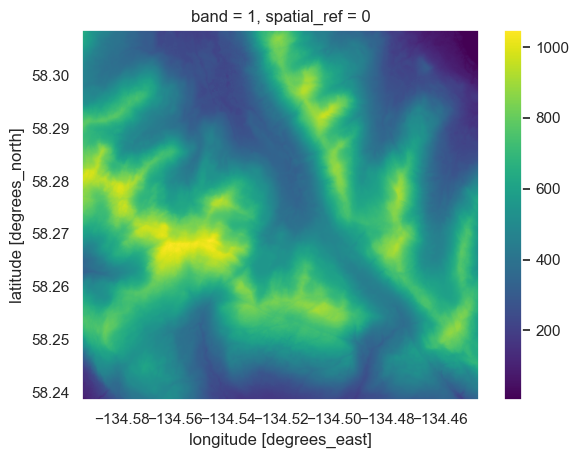

In [10]:
dem_powderpatch.plot()

"The DEM coord system is in geographic projection (latitude/longitude). WindNinja only supports projected coordinate systems (e.g., UTM)"

So the last step is to save a version of the `dem_powderpatch` which is in UTM

In [11]:
# so our DEM is in EPSG:4326, which is fine for the plotting and clipping with lat/long, but we need to reproject it to UTM for WindNinja
# The projection converts the globe to a flat surface, which is necessary for accurate distance and area calculations.
# WindNinja requires the DEM to be in a projected coordinate system, such as UTM
# The UTM (Universal Transverse Mercator) projection is a widely used projected coordinate system

# The area of Juneau Alaska is in UTM zone 8N, which is EPSG:32608
dem_powderpatch_utm = dem_powderpatch.rio.reproject("EPSG:32608")
# Save the reprojected DEM
dem_powderpatch_utm.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_clipped_juneau_powderpatch_utm_2m.tif")

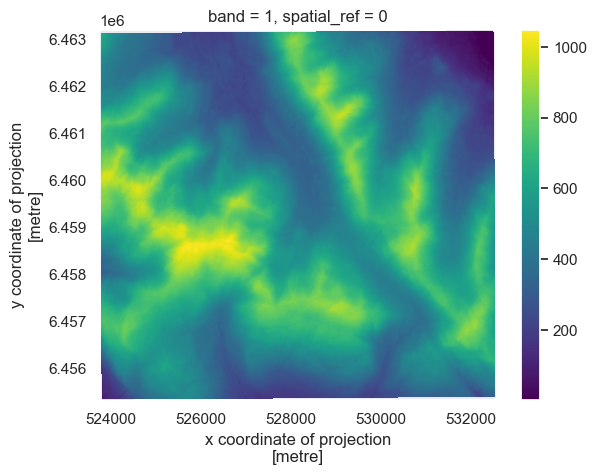

In [12]:
dem_powderpatch_utm.plot()

Looks good now. 

In [13]:
print("Original CRS of the Powder Patch DEM:", dem_powderpatch.rio.crs)
print("Projected CRS of the Powder Patch DEM:", dem_powderpatch_utm.rio.crs)

Original CRS of the Powder Patch DEM: EPSG:4326
Projected CRS of the Powder Patch DEM: EPSG:32608


In [14]:
# out of curiousily, look at what the Origional Arctic DEM CRS is, 
# Open the ArcticDEM file
filepath = '/hdd/snow_hydrology/DEMs/ArcticDEM/'
filename =  '40_05_2_2_2m_v4.1_dem.tif'

arctic_dem = rioxarray.open_rasterio(os.path.join(filepath, filename), masked=True)
print("Original CRS of Arctic DEM (before editing for clipping):", arctic_dem.rio.crs)

Original CRS of Arctic DEM (before editing for clipping): EPSG:3413


Okay, we are good to move on for now, but this is all likely useful in the future. 

New Wind Ninja error with the DEM, 

"The input dataset contains pixels with no data. These datasets cannot be used by Wind Ninja, would you like to attempt to fill those pixels?"

In [15]:
# check the dem_powderpatch_utm for missing data
print("total pixels:", dem_powderpatch_utm.sum().values)
print("# that are nan:", dem_powderpatch_utm.isnull().sum().values)

total pixels: 10533617000.0
# that are nan: 286558


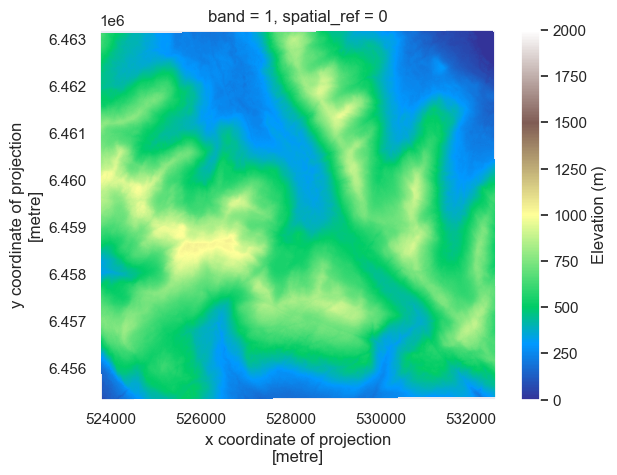

In [16]:
dem_powderpatch_utm.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})

In [17]:
dem_powderpatch_utm.squeeze()

<xarray.DataArray (y: 4240, x: 4769)> Size: 81MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4240, 4769), dtype=float32)
Coordinates:
  * x            (x) float64 38kB 5.237e+05 5.237e+05 ... 5.326e+05 5.326e+05
  * y            (y) float64 34kB 6.463e+06 6.463e+06 ... 6.455e+06 6.455e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1652.4415283203
    STATISTICS_MEAN:           295.53387922007
    STATISTICS_MINIMUM:        -0.30414265394211
    STATISTICS_STDDEV:         359.77932597602
    STATISTICS_VALID_PERCENT:  99.999
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0

So, let's interpolate first, then resample the dataset to ensure there is no missing data... 

In [18]:
# # Load your DEM
# dem = rxr.open_rasterio("your_dem.tif", masked=True).squeeze()
dem = dem_powderpatch_utm.squeeze()

# Check for missing data
nodata_mask = np.isnan(dem)

# Fill missing data with nearest neighbor
filled = dem.copy()
filled.data[nodata_mask] = ndimage.generic_filter(
    dem.data,
    function=lambda x: np.nanmean(x),
    size=5,  # 5x5 neighborhood
    mode='mirror'
)[nodata_mask]

# Replace DEM data
dem.data = filled

# Save the filled DEM
dem.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_clipped_juneau_powderpatch_filled_utm_2m.tif")
# dem.rio.to_raster("your_dem_filled.tif")

/tmp/ipykernel_946904/2979835991.py:12: RuntimeWarning: Mean of empty slice
  function=lambda x: np.nanmean(x),


In [24]:
# check for missing data now that we filled everything... 
print("total pixels in the OG:", dem_powderpatch_utm.sum().values)
print("# that are nan without filling:", dem_powderpatch_utm.isnull().sum().values)
print("# that are nan with    filling:", dem.isnull().sum().values)

total pixels in the OG: 10533617000.0
# that are nan without filling: 286558
# that are nan with    filling: 251643


So that filling opion did not fill all the missing data... 

In [1]:
# def iterative_fill(array, max_iter=10):
#     filled = array.copy()
#     for _ in range(max_iter):
#         mask = np.isnan(filled)
#         if not np.any(mask):
#             break
#         # Fill from neighbors
#         new_values = ndimage.generic_filter(
#             filled,
#             function=lambda x: np.nanmean(x),
#             size=5,
#             mode='mirror'
#         )
#         filled[mask] = new_values[mask]
#     return filled

# # Apply to your DEM data
# dem = dem_powderpatch_utm.squeeze()
# # Fill missing data iteratively
# # Note: Adjust max_iter based on how many iterations you want to perform
# # This will fill the missing data iteratively, using the mean of neighboring pixels
# # This is useful for larger datasets or when the missing data is more complex
# filled_array = iterative_fill(dem.data, max_iter=10)
# dem.data = filled_array

In [ ]:
# print("# that are nan with iterative filling:", dem.isnull().sum().values)

Since the iterative fill is taking so long to run, let's try a faster option...

In [25]:
def smart_fill_nans(data, max_iter=50):
    filled = data.copy()
    for _ in range(max_iter):
        nan_mask = np.isnan(filled)
        if not np.any(nan_mask):
            break

        # Get 4-neighbor average but only for NaNs
        neighbors_sum = (
            np.roll(filled, 1, axis=0) +
            np.roll(filled, -1, axis=0) +
            np.roll(filled, 1, axis=1) +
            np.roll(filled, -1, axis=1)
        )

        neighbors_count = (
            (~np.isnan(np.roll(filled, 1, axis=0))).astype(int) +
            (~np.isnan(np.roll(filled, -1, axis=0))).astype(int) +
            (~np.isnan(np.roll(filled, 1, axis=1))).astype(int) +
            (~np.isnan(np.roll(filled, -1, axis=1))).astype(int)
        )

        avg_neighbors = neighbors_sum / np.where(neighbors_count == 0, np.nan, neighbors_count)

        updated = filled.copy()
        updated[nan_mask] = avg_neighbors[nan_mask]

        # Only update those that changed
        filled[nan_mask] = np.where(np.isnan(avg_neighbors[nan_mask]), filled[nan_mask], avg_neighbors[nan_mask])

    return filled


dem_array = dem_powderpatch_utm.data.squeeze()
filled_array = smart_fill_nans(dem_array)

# Replace DEM data and verify
dem.data[:] = filled_array
print("Remaining NaNs:", np.isnan(dem.data).sum())

Remaining NaNs: 286558


### Now, we can resample the filled DEM

In [24]:
# Resample to 10m resolution
dem_10m = dem.rio.reproject(
    dem.rio.crs,
    shape=(
        int(dem.rio.height * 2 / 10),  # new height
        int(dem.rio.width * 2 / 10)    # new width
    ),
    resampling=rasterio.enums.Resampling.bilinear  # or average, cubic (using bilinear (or cublic) for elevation data is better compared to nearest)
)

dem_10m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_clipped_juneau_powderpatch_filled_utm_10m.tif")

In [21]:
# Resample to 50m resolution
dem_50m = dem.rio.reproject(
    dem.rio.crs,
    shape=(
        int(dem.rio.height * 2 / 50),  # new height
        int(dem.rio.width * 2 / 50)    # new width
    ),
    resampling=rasterio.enums.Resampling.bilinear  # or average, cubic
)

dem_50m.rio.to_raster("/hdd/snow_hydrology/DEMs/ArcticDEM_edits/dem_clipped_juneau_powderpatch_filled_utm_50m.tif")

In [22]:
# check for missing data now that we filled everything... 
print("total pixels in the OG:", dem_powderpatch_utm.sum().values)
print("# that are nan without filling:", dem_powderpatch_utm.isnull().sum().values)
print("# that are nan with    filling:", dem.isnull().sum().values)
print("# that are nan with    10m filling:", dem_10m.isnull().sum().values)
print("# that are nan with    50m filling:", dem_50m.isnull().sum().values)

total pixels in the OG: 10533617000.0
# that are nan without filling: 286558
# that are nan with    filling: 286558
# that are nan with    10m filling: 11448
# that are nan with    50m filling: 430


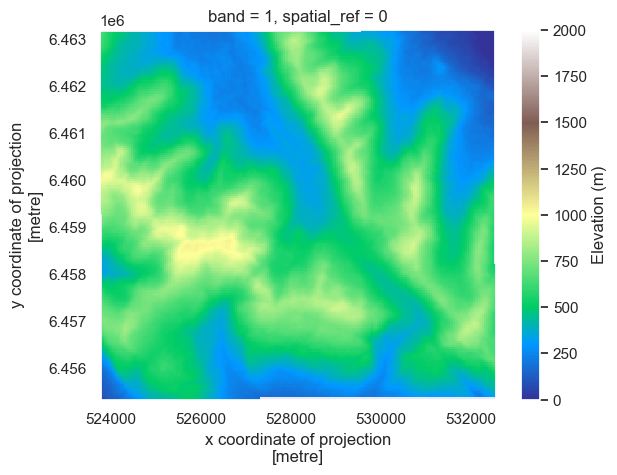

In [23]:
dem_50m.squeeze().plot(cmap='terrain', vmin=0, vmax=2000, cbar_kwargs={'label': 'Elevation (m)'})

## Now, the wind data

We just want to save a week or a month of a wind speed and wind direction for the clipped area defined above to test...

In [13]:
filepath = "/hdd/snow_hydrology/hrrrak/netcdf/"
filename = "hrrrak_merged_grib_f567_WY2025_test1.nc"

# load data
ds_hrrr = xr.open_dataset(filepath + filename)
ds_hrrr

<xarray.Dataset> Size: 413MB
Dimensions:                  (time: 4722, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 38kB 2024-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 38kB ...
    valid_time               (time) datetime64[ns] 38kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables: (12/52)
    pt                       (time, y, x) float32 8MB ...
    temp                     (time, y, x) float32 8MB ...
    d2m                      (time, y, x) float32 8MB ...
    sh2                      (time, y, x) float32 8MB ...
    rh                       (time, y, x) float32 8MB ...
    u10                      (time, y, x) float32 8MB ...
    ...                       ...
    lai                      (time, y, x) float32 8MB ...
    vgtyp                    (time, y, x) float32 8MB ...
    cloud_total              (time, y, x) float32 8MB ...
    cloud_high               (time, y, x) float32 8MB ...
    cloud_low                (time, y, x) float32 8MB ...
    wind                     (time, y, x) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

(array([7.52547e+05, 7.28714e+05, 3.31795e+05, 1.18910e+05, 3.62720e+04,
        1.08340e+04, 2.99700e+03, 9.52000e+02, 1.94000e+02, 2.50000e+01]),
 array([1.94638642e-03, 3.35441160e+00, 6.70687675e+00, 1.00593424e+01,
        1.34118071e+01, 1.67642708e+01, 2.01167374e+01, 2.34692020e+01,
        2.68216667e+01, 3.01741314e+01, 3.35265961e+01]),
 <BarContainer object of 10 artists>)

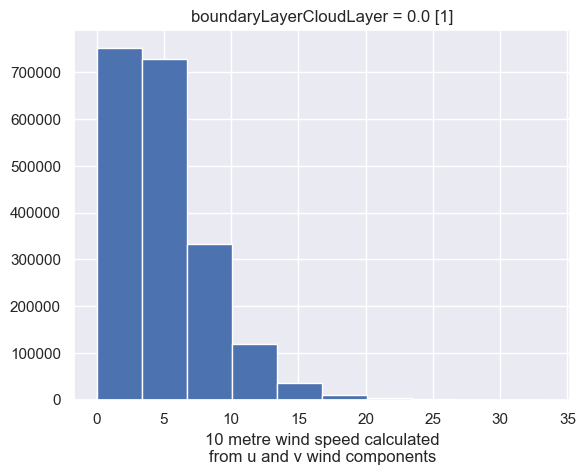

In [14]:
ds_hrrr.wind.plot()

In [ ]:
# Now we know we have the wind speed, calculated from u and v components, in the ds_hrrr dataset.
# And we want to calculate the wind direction from the u and v components.
# The wind direction is calculated as the arctangent of the ratio of the u and v
# components, using the numpy arctan2 function.
# The wind direction is given in degrees, with 0 degrees being north, 90 degrees
# being east, 180 degrees being south, and 270 degrees being west.

# u10 = west-east wind component (m/s)
# v10 = south-north wind component (m/s)

# the general equation being, 
# wind_dir = (180 / np.pi) * np.arctan2(-u10, -v10)
# wind_dir = (wind_dir + 360) % 360  # Convert to compass bearing

# implemented, 
ds_hrrr["wind_direction"] = (180 * np.arctan2(ds_hrrr["u10"], ds_hrrr["v10"]) / np.pi)
ds_hrrr.wind_direction.plot()

A result of 
* 0° means wind is from the north
* 90° = from the east
* 180° = from the south
* 270° = from the west

In [ ]:
#rename `ds_hrrr['wind']` to `ds_hrrr[wind_speed]`
ds_hrrr = ds_hrrr.rename({"wind": "wind_speed"})

In [ ]:
# Now we want to save a very simple version of a dataset, with only the wind speed and direction, for use in WindNinja.
ds_hrrr_wind = ds_hrrr[["wind_speed", "wind_direction"]].copy()
ds_hrrr_wind

In [ ]:
# We also need to clip the dataset to the Powder Patch Domain, we can do this using the `rio.clip_box` method.
ds_hrrr_wind_powderpatch = ds_hrrr_wind.rio.clip_box(
    minx=xmin, maxx=xmax, miny=ymin, maxy=ymax)

In [ ]:
# We want to create a short time series of wind speed and direction for the Powder Patch area.
# We can use the `sel` method to select a specific time range.
# For example, we can select the first 10 time steps.
ds_hrrr_wind_powderpatch_short = ds_hrrr_wind_powderpatch.sel(time=slice("2024-10-01", "2024-10-10"))
ds_hrrr_wind_powderpatch_short

In [ ]:
# Save the short time series of wind speed and direction to a NetCDF file
ds_hrrr_wind_short.rio.to_raster("/hdd/snow_hydrology/hrrrak/netcdf/hrrr_wind_powder_patch.nc")